#  Решение задачи регрессии при помощи пакета `torch`. Метрики.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

__Выполнила Ларькова Дарья__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/nn.html
* https://pytorch.org/docs/stable/optim.html
* https://github.com/Lightning-AI/torchmetrics
* https://pytorch.org/docs/stable/generated/torch.no_grad.html
* https://pytorch-lightning.readthedocs.io/en/2.1.2/pytorch/ecosystem/metrics.html#torchmetrics

## Задачи для совместного разбора

In [2]:
import torch as th

1\. Используя реализацию из `torch.nn`, решите задачу регрессии. Для расчета градиентов воспользуйтесь возможностями по автоматическому дифференцированию `torch`. В качестве функции потерь используйте собственную реализацию MSE. Для настройки весов реализуйте пакетный градиентный спуск с использованием `torch.optim.SGD`.

In [3]:
from sklearn.datasets import make_regression

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y)

In [4]:
import torch.nn as nn

In [5]:
def mse_loss(y_pred, y_true):
    return th.mean((y_pred - y_true) ** 2)

In [6]:
class LinearRegression(nn.Module):
    def __init__(self, input_dim):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x).squeeze()

In [7]:
input_dim = X.shape[1]
learning_rate = 0.01
batch_size = 32
num_epochs = 1000

In [8]:
model = LinearRegression(input_dim)

In [9]:
optimizer = th.optim.SGD(model.parameters(), lr=learning_rate) # Оптимизатор (пакетный градиентный спуск)

In [10]:
for epoch in range(num_epochs):
    y_pred = model(X)
    loss = mse_loss(y_pred, y)

    # Обратный проход
    optimizer.zero_grad()  # обнуление градиентов
    loss.backward()        # автоматическое дифференцирование
    optimizer.step()       # обновление весов

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():.4f}')

Epoch [100/1000], Loss: 226.8353
Epoch [200/1000], Loss: 7.2958
Epoch [300/1000], Loss: 0.2938
Epoch [400/1000], Loss: 0.0132
Epoch [500/1000], Loss: 0.0006
Epoch [600/1000], Loss: 0.0000
Epoch [700/1000], Loss: 0.0000
Epoch [800/1000], Loss: 0.0000
Epoch [900/1000], Loss: 0.0000
Epoch [1000/1000], Loss: 0.0000


In [11]:
with th.no_grad():
    trained_pred = model(X)
    final_loss = mse_loss(trained_pred, y)
    print(final_loss.item())

5.434281646898853e-08


In [12]:
coef

array([ 5.63754967, 86.47223763, 27.34070719, 41.48195023])

In [13]:
print(f"Learned weights: {model.linear.weight.data.numpy()[0]}")
print(f"Learned bias: {model.linear.bias.data.item():.4f}")

Learned weights: [ 5.637558 86.47203  27.340784 41.48182 ]
Learned bias: 0.5000


## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию полносвязного слоя из `torch.nn` решите задачу регрессии. В качестве функции потерь используйте реализацию MSE из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`. Для создания модели опишите класс `SineModel`.

Предлагаемая архитектура нейронной сети:
1. Полносвязный слой с 100 нейронами
2. Активация ReLU
3. Полносвязный слой с 1 нейроном

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).

Выведите график изменения значения функции потерь в процессе обучения. Логику расчета значения функции потерь на уровне эпохи реализуйте самостоятельно.

- [ ] Проверено на семинаре

In [14]:
import torch

X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

In [15]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from typing import Tuple

In [16]:
class SineModel(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_out: int) -> None:
        super().__init__()
        self.fc1 = nn.Linear(n_features, n_hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(n_hidden, n_out)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        x = self.fc1(X)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [17]:
n_features = 1
n_hidden = 100
n_out = 1
learning_rate = 0.01
batch_size = 10
num_epochs = 2000

In [18]:
model = SineModel(n_features, n_hidden, n_out)
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [19]:
predictions_history = []
loss_history = []

# Создание DataLoader для мини-пакетного обучения
dataset = torch.utils.data.TensorDataset(X, y)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in range(num_epochs):
    epoch_loss = 0.0
    batch_count = 0

    # Мини-пакетный градиентный спуск
    for batch_X, batch_y in dataloader:
        # Прямой проход
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)

        # Обратный проход
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        epoch_loss += loss.item()
        batch_count += 1

    # Средняя потеря за эпоху
    avg_epoch_loss = epoch_loss / batch_count
    loss_history.append(avg_epoch_loss)

    if epoch in [0, 100, 500, 1000, 1500, num_epochs - 1]:
        with torch.no_grad():
            current_pred = model(X)
            predictions_history.append((epoch, current_pred.numpy()))

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.6f}')

Epoch [100/2000], Loss: 0.157863
Epoch [200/2000], Loss: 0.122016
Epoch [300/2000], Loss: 0.087347
Epoch [400/2000], Loss: 0.058757
Epoch [500/2000], Loss: 0.040626
Epoch [600/2000], Loss: 0.027609
Epoch [700/2000], Loss: 0.019557
Epoch [800/2000], Loss: 0.014908
Epoch [900/2000], Loss: 0.011519
Epoch [1000/2000], Loss: 0.009702
Epoch [1100/2000], Loss: 0.007676
Epoch [1200/2000], Loss: 0.006598
Epoch [1300/2000], Loss: 0.005739
Epoch [1400/2000], Loss: 0.005229
Epoch [1500/2000], Loss: 0.004209
Epoch [1600/2000], Loss: 0.003661
Epoch [1700/2000], Loss: 0.003204
Epoch [1800/2000], Loss: 0.002860
Epoch [1900/2000], Loss: 0.002500
Epoch [2000/2000], Loss: 0.002235


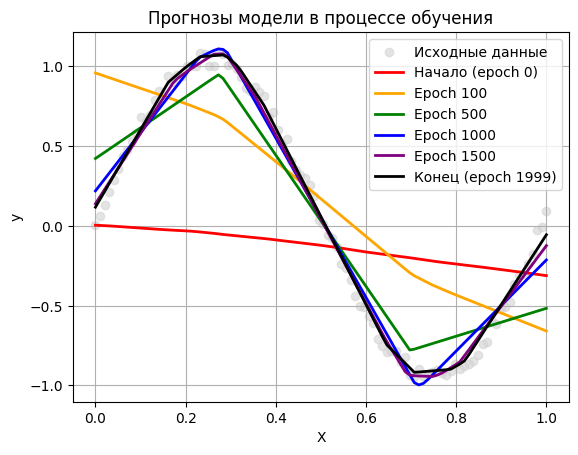

In [20]:
plt.scatter(X.numpy(), y.numpy(), alpha=0.6, label='Исходные данные', color='lightgray')
colors = ['red', 'orange', 'green', 'blue', 'purple', 'black']
labels = ['Начало (epoch 0)', 'Epoch 100', 'Epoch 500', 'Epoch 1000', 'Epoch 1500', f'Конец (epoch {num_epochs-1})']

for i, (epoch_num, pred) in enumerate(predictions_history):
    plt.plot(X.numpy(), pred, color=colors[i], linewidth=2, label=labels[i])

plt.xlabel('X')
plt.ylabel('y')
plt.title('Прогнозы модели в процессе обучения')
plt.legend()
plt.grid()

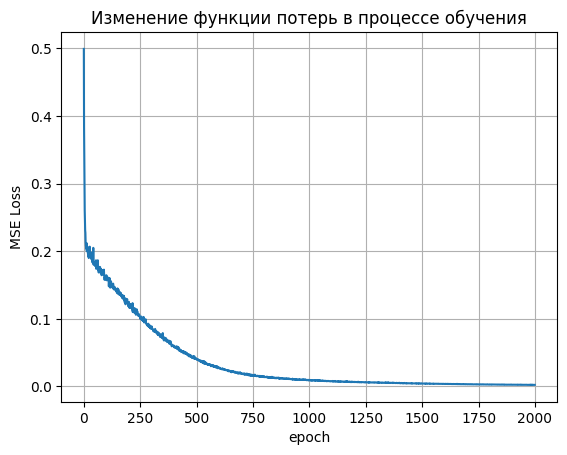

In [21]:
plt.plot(loss_history)
plt.xlabel('epoch')
plt.ylabel('MSE Loss')
plt.title('Изменение функции потерь в процессе обучения')
plt.grid()

In [22]:
with torch.no_grad():
    final_pred = model(X)
    final_loss = criterion(final_pred, y)
    print(final_loss.item())
    print(sum(p.numel() for p in model.parameters()))

0.002293113386258483
301


<p class="task" id="2"></p>

2\. Повторите решение задачи 1, изменив модель. Для создания модели создайте объект класса `nn.Sequential`.

Предлагаемая архитектура нейронной сети:
1. Полносвязный слой с 50 нейронами
2. Активация Tanh
3. Полносвязный слой с 1 нейроном

- [ ] Проверено на семинаре

In [23]:
import torch

X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

In [24]:
import torch.nn as nn
import matplotlib.pyplot as plt
from typing import Tuple

In [25]:
model = nn.Sequential(
    nn.Linear(1, 50),    # Полносвязный слой с 50 нейронами
    nn.Tanh(),           # Активация Tanh
    nn.Linear(50, 1)     # Полносвязный слой с 1 нейроном
)

In [26]:
learning_rate = 0.01
batch_size = 10
num_epochs = 2000

In [27]:
criterion = nn.MSELoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

In [28]:
predictions_history = []
loss_history = []
dataset = torch.utils.data.TensorDataset(X, y)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)
for epoch in range(num_epochs):
    epoch_loss = 0.0
    batch_count = 0
    # Мини-пакетный градиентный спуск
    for batch_X, batch_y in dataloader:
        # Прямой проход
        y_pred = model(batch_X)
        loss = criterion(y_pred, batch_y)

        # Обратный проход
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        batch_count += 1

    # Средняя потеря за эпоху
    avg_epoch_loss = epoch_loss / batch_count
    loss_history.append(avg_epoch_loss)

    if epoch in [0, 100, 500, 1000, 1500, num_epochs - 1]:
        with torch.no_grad():
            current_pred = model(X)
            predictions_history.append((epoch, current_pred.numpy()))

    if (epoch + 1) % 100 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_epoch_loss:.6f}')

Epoch [100/2000], Loss: 0.207339
Epoch [200/2000], Loss: 0.208537
Epoch [300/2000], Loss: 0.205029
Epoch [400/2000], Loss: 0.206805
Epoch [500/2000], Loss: 0.206139
Epoch [600/2000], Loss: 0.203848
Epoch [700/2000], Loss: 0.207154
Epoch [800/2000], Loss: 0.198717
Epoch [900/2000], Loss: 0.200588
Epoch [1000/2000], Loss: 0.199589
Epoch [1100/2000], Loss: 0.195051
Epoch [1200/2000], Loss: 0.196867
Epoch [1300/2000], Loss: 0.189431
Epoch [1400/2000], Loss: 0.182895
Epoch [1500/2000], Loss: 0.177946
Epoch [1600/2000], Loss: 0.167243
Epoch [1700/2000], Loss: 0.155108
Epoch [1800/2000], Loss: 0.133515
Epoch [1900/2000], Loss: 0.107025
Epoch [2000/2000], Loss: 0.079491


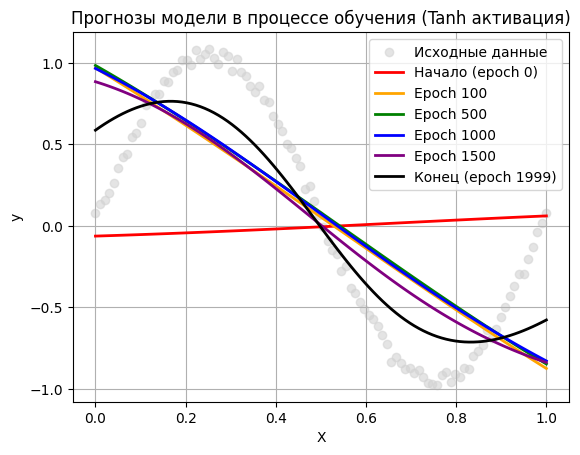

In [29]:
plt.scatter(X.numpy(), y.numpy(), alpha=0.6, label='Исходные данные', color='lightgray')
colors = ['red', 'orange', 'green', 'blue', 'purple', 'black']
labels = ['Начало (epoch 0)', 'Epoch 100', 'Epoch 500', 'Epoch 1000', 'Epoch 1500', f'Конец (epoch {num_epochs-1})']

for i, (epoch_num, pred) in enumerate(predictions_history):
    plt.plot(X.numpy(), pred, color=colors[i], linewidth=2, label=labels[i])

plt.xlabel('X')
plt.ylabel('y')
plt.title('Прогнозы модели в процессе обучения (Tanh активация)')
plt.legend()
plt.grid()

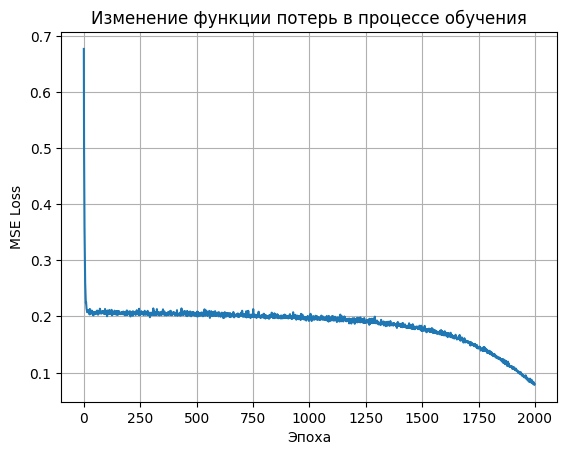

In [30]:
plt.plot(loss_history)
plt.xlabel('Эпоха')
plt.ylabel('MSE Loss')
plt.title('Изменение функции потерь в процессе обучения')
plt.grid()

In [31]:
with torch.no_grad():
    final_pred = model(X)
    final_loss = criterion(final_pred, y)
    print(final_loss.item())
    print(f'Количество параметров модели: {sum(p.numel() for p in model.parameters())}')
    print(model)

0.07824105024337769
Количество параметров модели: 151
Sequential(
  (0): Linear(in_features=1, out_features=50, bias=True)
  (1): Tanh()
  (2): Linear(in_features=50, out_features=1, bias=True)
)


<p class="task" id="3"></p>

3\. Используя реализацию полносвязного слоя из `torch.nn`, решите задачу регрессии. В качестве функции потерь используйте реализацию MSE из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`. Перенесите вычисления на GPU и сравните время обучения с и без использования GPU. Решение должно корректно работать в случае отсутствия GPU без дополнительных изменений в коде.

- [ ] Проверено на семинаре

In [32]:
from sklearn.datasets import make_regression
import torch as th

X, y, coef = make_regression(
    n_samples=10000,
    n_features=10,
    n_informative=6,
    coef=True,
    bias=0.5,
    random_state=42
)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [33]:
import torch
import torch.nn as nn
import time
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [34]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); device

device(type='cuda')

In [35]:
class RegressionModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super(RegressionModel, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [36]:
input_dim = X.shape[1]
hidden_dim = 64
output_dim = 1
# lr=0.01 на ненормированном make_regression был слишком большим и приводил к деградации обучения.
learning_rate = 0.003
batch_size = 128
num_epochs = 50

In [37]:
def train_model(use_gpu=False, initial_state=None, seed=42):
    """Обучение одной и той же модели на CPU или CUDA.

    initial_state позволяет честно сравнивать устройства: обе модели стартуют
    с абсолютно одинаковых весов и видят батчи в одинаковом порядке.
    """
    if use_gpu and not torch.cuda.is_available():
        return None

    current_device = torch.device('cuda' if use_gpu else 'cpu')
    model = RegressionModel(input_dim, hidden_dim, output_dim)
    if initial_state is not None:
        model.load_state_dict(initial_state)
    model = model.to(current_device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    dataset = torch.utils.data.TensorDataset(X, y)
    generator = torch.Generator().manual_seed(seed)
    dataloader = torch.utils.data.DataLoader(
        dataset, batch_size=batch_size, shuffle=True, generator=generator
    )

    if current_device.type == 'cuda':
        torch.cuda.synchronize()
    start_time = time.perf_counter()

    loss_history = []
    for epoch in range(num_epochs):
        model.train()
        epoch_loss_sum = 0.0
        n_samples = 0

        for batch_X, batch_y in dataloader:
            batch_X = batch_X.to(current_device, non_blocking=True)
            batch_y = batch_y.to(current_device, non_blocking=True)

            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            bs = batch_X.shape[0]
            epoch_loss_sum += loss.item() * bs
            n_samples += bs

        avg_loss = epoch_loss_sum / n_samples
        loss_history.append(avg_loss)

        if (epoch + 1) % 10 == 0:
            print(f'{current_device.type.upper()} | Epoch [{epoch+1}/{num_epochs}] | MSE: {avg_loss:.6f}')

    if current_device.type == 'cuda':
        torch.cuda.synchronize()
    training_time = time.perf_counter() - start_time

    model.eval()
    with torch.no_grad():
        X_device = X.to(current_device)
        y_device = y.to(current_device)
        final_pred = model(X_device)
        final_loss = criterion(final_pred, y_device).item()

    return {
        'device': current_device.type,
        'time': training_time,
        'final_loss': final_loss,
        'loss_history': loss_history,
        'model': model,
    }

In [38]:
# Одинаковая начальная инициализация для честного CPU/GPU сравнения.
torch.manual_seed(42)
reference_model = RegressionModel(input_dim, hidden_dim, output_dim)
initial_state = {k: v.detach().cpu().clone() for k, v in reference_model.state_dict().items()}

print('Обучение на CPU')
cpu_result = train_model(use_gpu=False, initial_state=initial_state)

if torch.cuda.is_available():
    print('\nОбучение на GPU')
    gpu_result = train_model(use_gpu=True, initial_state=initial_state)
else:
    gpu_result = None
    print('\nCUDA недоступна — GPU-эксперимент корректно пропущен.')

Обучение на CPU
CPU | Epoch [10/50] | MSE: 0.442407
CPU | Epoch [20/50] | MSE: 0.197309
CPU | Epoch [30/50] | MSE: 0.123828
CPU | Epoch [40/50] | MSE: 0.085598
CPU | Epoch [50/50] | MSE: 0.063044

Обучение на GPU
CUDA | Epoch [10/50] | MSE: 0.442407
CUDA | Epoch [20/50] | MSE: 0.197309
CUDA | Epoch [30/50] | MSE: 0.123828
CUDA | Epoch [40/50] | MSE: 0.085598
CUDA | Epoch [50/50] | MSE: 0.063045


Размер батча: 128
Количество эпох: 50
Размер данных: 10000 samples, 10 features

CPU: time=1.597 s, final MSE=0.069530
GPU: time=3.336 s, final MSE=0.069528
Ускорение CPU/GPU: 0.48x


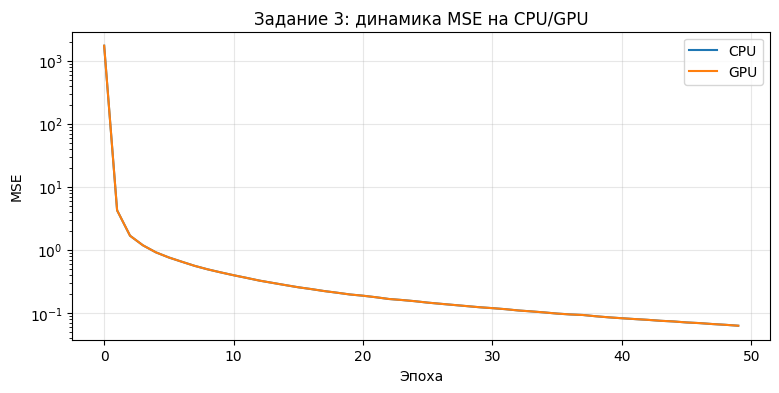

In [39]:
print(f"Размер батча: {batch_size}")
print(f"Количество эпох: {num_epochs}")
print(f"Размер данных: {X.shape[0]} samples, {X.shape[1]} features")
print(f"\nCPU: time={cpu_result['time']:.3f} s, final MSE={cpu_result['final_loss']:.6f}")

plt.figure(figsize=(9, 4))
plt.plot(cpu_result['loss_history'], label='CPU')

if gpu_result is not None:
    print(f"GPU: time={gpu_result['time']:.3f} s, final MSE={gpu_result['final_loss']:.6f}")
    speedup = cpu_result['time'] / gpu_result['time']
    print(f"Ускорение CPU/GPU: {speedup:.2f}x")
    plt.plot(gpu_result['loss_history'], label='GPU')
else:
    print('GPU: CUDA недоступна, сравнение времени пропущено без ошибки.')

plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.title('Задание 3: динамика MSE на CPU/GPU')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<p class="task" id="4"></p>

4\. Повторите решение задач 1-2, используя для расчета значения функции потерь за эпоху метрику `MeanMetric` из пакета `torchmetrics`. Добавьте в цикл обучения расчет метрики $R^2$ (воспользуйтесь реализацией из `torchmetrics`). Выведите на экран график изменения значения функции потерь и метрики $R^2$ по эпохам в процессе обучения.

In [40]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('torchmetrics') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', 'torchmetrics'])

In [41]:
import torch
import torch.nn as nn
import torchmetrics
import matplotlib.pyplot as plt
import numpy as np

In [42]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

In [43]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu'); device

device(type='cuda')

In [44]:
X = X.to(device)
y = y.to(device)

In [45]:
class SineModelReLU(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_out: int) -> None:
        super().__init__()
        self.fc1 = nn.Linear(n_features, n_hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(n_hidden, n_out)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        x = self.fc1(X)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [46]:
SineModelTanh = nn.Sequential(
    nn.Linear(1, 50),    # Полносвязный слой с 50 нейронами
    nn.Tanh(),           # Активация Tanh
    nn.Linear(50, 1)     # Полносвязный слой с 1 нейроном
)

In [47]:
def train_model(model, model_name, X, y):
    learning_rate = 0.01
    batch_size = 10
    num_epochs = 2000

    model = model.to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    mse_metric = torchmetrics.MeanMetric().to(device)
    r2_metric = torchmetrics.R2Score().to(device)

    mse_history = []
    r2_history = []
    predictions_history = []

    dataset = torch.utils.data.TensorDataset(X, y)
    dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

    for epoch in range(num_epochs):
        model.train()
        mse_metric.reset()

        for batch_X, batch_y in dataloader:
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            mse_metric.update(loss.detach())

        epoch_mse = mse_metric.compute().item()

        model.eval()
        r2_metric.reset()
        with torch.no_grad():
            full_pred = model(X)
            r2_metric.update(full_pred, y)
            epoch_r2 = r2_metric.compute().item()

        mse_history.append(epoch_mse)
        r2_history.append(epoch_r2)

        if epoch in [0, 100, 500, 1000, 1500, num_epochs - 1]:
            predictions_history.append((epoch, full_pred.detach().cpu().numpy()))

        if (epoch + 1) % 100 == 0:
            print(f'{model_name} | Epoch [{epoch+1}/{num_epochs}], MSE: {epoch_mse:.6f}, R²: {epoch_r2:.4f}')

    return mse_history, r2_history, predictions_history, model

In [48]:
# Обучение обеих моделей
mse_history_relu, r2_history_relu, pred_history_relu, model_relu = train_model(
    SineModelReLU(1, 100, 1), "SineModelReLU", X, y
)

mse_history_tanh, r2_history_tanh, pred_history_tanh, model_tanh = train_model(
    SineModelTanh, "SineModelTanh", X, y
)

SineModelReLU | Epoch [100/2000], MSE: 0.171437, R²: 0.6680
SineModelReLU | Epoch [200/2000], MSE: 0.141390, R²: 0.7322
SineModelReLU | Epoch [300/2000], MSE: 0.100718, R²: 0.8087
SineModelReLU | Epoch [400/2000], MSE: 0.070760, R²: 0.8607
SineModelReLU | Epoch [500/2000], MSE: 0.047457, R²: 0.9073
SineModelReLU | Epoch [600/2000], MSE: 0.032040, R²: 0.9386
SineModelReLU | Epoch [700/2000], MSE: 0.020387, R²: 0.9603
SineModelReLU | Epoch [800/2000], MSE: 0.014363, R²: 0.9717
SineModelReLU | Epoch [900/2000], MSE: 0.010406, R²: 0.9785
SineModelReLU | Epoch [1000/2000], MSE: 0.009378, R²: 0.9836
SineModelReLU | Epoch [1100/2000], MSE: 0.006758, R²: 0.9872
SineModelReLU | Epoch [1200/2000], MSE: 0.005587, R²: 0.9896
SineModelReLU | Epoch [1300/2000], MSE: 0.004519, R²: 0.9914
SineModelReLU | Epoch [1400/2000], MSE: 0.003753, R²: 0.9925
SineModelReLU | Epoch [1500/2000], MSE: 0.003182, R²: 0.9938
SineModelReLU | Epoch [1600/2000], MSE: 0.002725, R²: 0.9946
SineModelReLU | Epoch [1700/2000]

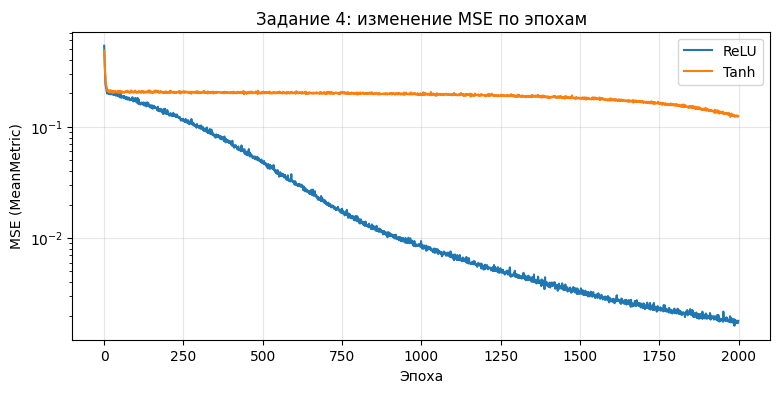

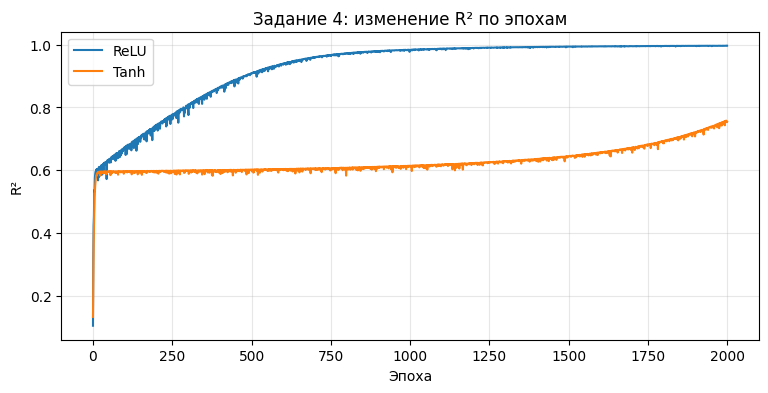

In [49]:
plt.figure(figsize=(9, 4))
plt.plot(mse_history_relu, label='ReLU')
plt.plot(mse_history_tanh, label='Tanh')
plt.xlabel('Эпоха')
plt.ylabel('MSE (MeanMetric)')
plt.title('Задание 4: изменение MSE по эпохам')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

plt.figure(figsize=(9, 4))
plt.plot(r2_history_relu, label='ReLU')
plt.plot(r2_history_tanh, label='Tanh')
plt.xlabel('Эпоха')
plt.ylabel('R²')
plt.title('Задание 4: изменение R² по эпохам')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

<p class="task" id="5"></p>

5\. Повторите решение задач 1-2, изменив функцию потерь. Обучите модель, используя три функции потерь: `MSELoss`, `L1Loss` и `HuberLoss` - и выведите на одном графике динамику изменения метрики $R^2$ по эпохам для каждой модели в процессе обучения. Добавьте подписи полученных кривых.

- [ ] Проверено на семинаре

In [50]:
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

In [51]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu');

In [52]:
X = X.to(device)
y = y.to(device)

In [53]:
class SineModelReLU(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_out: int) -> None:
        super().__init__()
        self.fc1 = nn.Linear(n_features, n_hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(n_hidden, n_out)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        x = self.fc1(X)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [54]:
SineModelTanh = nn.Sequential(
    nn.Linear(1, 50),    # Полносвязный слой с 50 нейронами
    nn.Tanh(),           # Активация Tanh
    nn.Linear(50, 1)     # Полносвязный слой с 1 нейроном
)

In [55]:
import copy

def train_model_with_losses(model, model_name, loss_functions, X, y, seed=42):
    learning_rate = 0.01
    batch_size = 10
    num_epochs = 2000

    initial_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
    results = {}

    for loss_name, criterion in loss_functions.items():
        print(f"\nОбучение {model_name} с функцией потерь {loss_name}:")
        print('-' * 50)

        current_model = copy.deepcopy(model)
        current_model.load_state_dict(initial_state)
        current_model = current_model.to(device)
        criterion = criterion.to(device)
        optimizer = torch.optim.SGD(current_model.parameters(), lr=learning_rate)

        r2_metric = torchmetrics.R2Score().to(device)
        r2_history = []
        loss_history = []

        generator = torch.Generator().manual_seed(seed)
        dataset = torch.utils.data.TensorDataset(X, y)
        dataloader = torch.utils.data.DataLoader(
            dataset, batch_size=batch_size, shuffle=True, generator=generator
        )

        for epoch in range(num_epochs):
            current_model.train()
            epoch_loss_sum = 0.0
            n_samples = 0

            for batch_X, batch_y in dataloader:
                y_pred = current_model(batch_X)
                loss = criterion(y_pred, batch_y)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

                bs = batch_X.shape[0]
                epoch_loss_sum += loss.item() * bs
                n_samples += bs

            avg_loss = epoch_loss_sum / n_samples

            current_model.eval()
            r2_metric.reset()
            with torch.no_grad():
                full_pred = current_model(X)
                r2_metric.update(full_pred, y)
                epoch_r2 = r2_metric.compute().item()

            r2_history.append(epoch_r2)
            loss_history.append(avg_loss)

            if (epoch + 1) % 500 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, R²: {epoch_r2:.4f}')

        results[loss_name] = {
            'r2_history': r2_history,
            'loss_history': loss_history,
            'model': current_model,
            'final_r2': r2_history[-1],
        }

    return results

In [56]:
loss_functions = {
    'MSE': nn.MSELoss(),
    'L1': nn.L1Loss(),
    'Huber': nn.HuberLoss(delta=1.0)  # delta - параметр для Huber loss
    # 0,5 * (y_true - y_pred)^2, если |y_true - y_pred| <= delta.
    # delta * |y_true - y_pred| - 0,5 * delta^2, если |y_true - y_pred| > delta.
}

In [57]:
results_relu = train_model_with_losses(SineModelReLU(1, 100, 1), "SineModelReLU", loss_functions, X, y)


Обучение SineModelReLU с функцией потерь MSE:
--------------------------------------------------
Epoch [500/2000], Loss: 0.038351, R²: 0.9186
Epoch [1000/2000], Loss: 0.007536, R²: 0.9848
Epoch [1500/2000], Loss: 0.003012, R²: 0.9940
Epoch [2000/2000], Loss: 0.001711, R²: 0.9966

Обучение SineModelReLU с функцией потерь L1:
--------------------------------------------------
Epoch [500/2000], Loss: 0.121884, R²: 0.9579
Epoch [1000/2000], Loss: 0.081776, R²: 0.9822
Epoch [1500/2000], Loss: 0.059790, R²: 0.9969
Epoch [2000/2000], Loss: 0.046861, R²: 0.9921

Обучение SineModelReLU с функцией потерь Huber:
--------------------------------------------------
Epoch [500/2000], Loss: 0.048936, R²: 0.7994
Epoch [1000/2000], Loss: 0.019328, R²: 0.9256
Epoch [1500/2000], Loss: 0.007008, R²: 0.9729
Epoch [2000/2000], Loss: 0.003565, R²: 0.9861


In [58]:
results_tanh = train_model_with_losses(SineModelTanh, "SineModelTanh", loss_functions, X, y)


Обучение SineModelTanh с функцией потерь MSE:
--------------------------------------------------
Epoch [500/2000], Loss: 0.196958, R²: 0.5930
Epoch [1000/2000], Loss: 0.182529, R²: 0.6443
Epoch [1500/2000], Loss: 0.114961, R²: 0.7819
Epoch [2000/2000], Loss: 0.010083, R²: 0.9805

Обучение SineModelTanh с функцией потерь L1:
--------------------------------------------------
Epoch [500/2000], Loss: 0.391327, R²: 0.5859
Epoch [1000/2000], Loss: 0.372867, R²: 0.6298
Epoch [1500/2000], Loss: 0.280885, R²: 0.8037
Epoch [2000/2000], Loss: 0.092340, R²: 0.9894

Обучение SineModelTanh с функцией потерь Huber:
--------------------------------------------------
Epoch [500/2000], Loss: 0.101265, R²: 0.5988
Epoch [1000/2000], Loss: 0.099824, R²: 0.6091
Epoch [1500/2000], Loss: 0.097287, R²: 0.6225
Epoch [2000/2000], Loss: 0.091281, R²: 0.6455


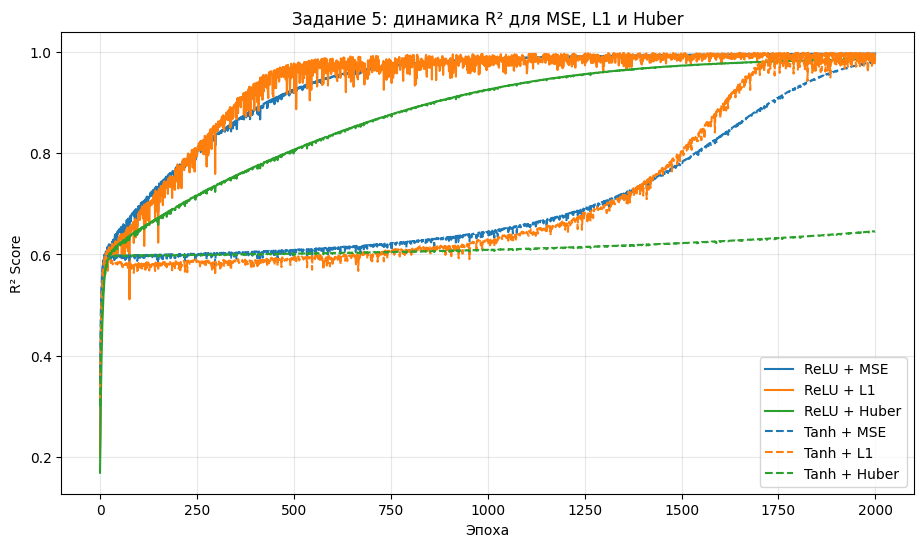

In [59]:
colors = {'MSE': 'tab:blue', 'L1': 'tab:orange', 'Huber': 'tab:green'}

plt.figure(figsize=(11, 6))
for loss_name, result in results_relu.items():
    plt.plot(result['r2_history'], color=colors[loss_name], linestyle='-',
             label=f'ReLU + {loss_name}')

for loss_name, result in results_tanh.items():
    plt.plot(result['r2_history'], color=colors[loss_name], linestyle='--',
             label=f'Tanh + {loss_name}')

plt.xlabel('Эпоха')
plt.ylabel('R² Score')
plt.title('Задание 5: динамика R² для MSE, L1 и Huber')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [60]:
print('Финальный R² после независимого обучения с одинаковой инициализацией:')
for architecture, results in [('ReLU', results_relu), ('Tanh', results_tanh)]:
    for loss_name, result in results.items():
        print(f'{architecture:4s} + {loss_name:5s}: R² = {result["final_r2"]:.4f}')

Финальный R² после независимого обучения с одинаковой инициализацией:
ReLU + MSE  : R² = 0.9966
ReLU + L1   : R² = 0.9921
ReLU + Huber: R² = 0.9861
Tanh + MSE  : R² = 0.9805
Tanh + L1   : R² = 0.9894
Tanh + Huber: R² = 0.6455


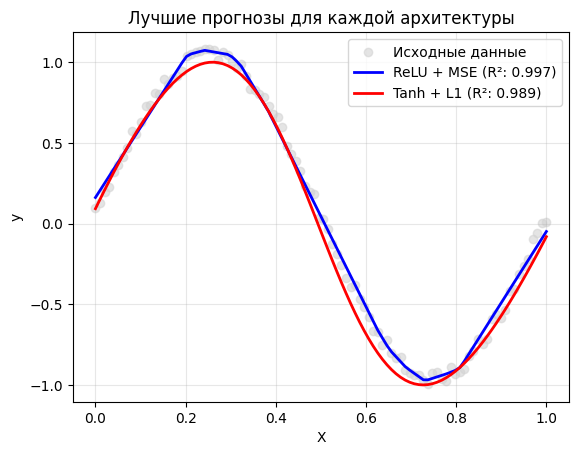

In [61]:
plt.scatter(X.cpu().numpy(), y.cpu().numpy(), alpha=0.6, label='Исходные данные', color='lightgray')
best_relu_loss = max(results_relu.keys(), key=lambda x: results_relu[x]['r2_history'][-1])
best_tanh_loss = max(results_tanh.keys(), key=lambda x: results_tanh[x]['r2_history'][-1])

with torch.no_grad():
    best_relu_pred = results_relu[best_relu_loss]['model'](X).cpu().numpy()
    best_tanh_pred = results_tanh[best_tanh_loss]['model'](X).cpu().numpy()

plt.plot(X.cpu().numpy(), best_relu_pred, 'b-', linewidth=2,
         label=f'ReLU + {best_relu_loss} (R²: {results_relu[best_relu_loss]["r2_history"][-1]:.3f})')
plt.plot(X.cpu().numpy(), best_tanh_pred, 'r-', linewidth=2,
         label=f'Tanh + {best_tanh_loss} (R²: {results_tanh[best_tanh_loss]["r2_history"][-1]:.3f})')

plt.xlabel('X')
plt.ylabel('y')
plt.title('Лучшие прогнозы для каждой архитектуры')
plt.legend()
plt.grid(True, alpha=0.3)

<p class="task" id="6"></p>

6\. Повторите решение задач 1-2, разделив датасет на обучающую и тестовую выборку в соотношении 80% на 20%. Обучите модель. Для тестовой выборки посчитайте и выведите на экран значения метрик:

- MAE;
- MAPE;
- MSE;
- MSLE (MeanSquaredLogError).


- [ ] Проверено на семинаре

In [62]:
import torch
import torch.nn as nn
import torchmetrics
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import numpy as np

In [63]:
torch.manual_seed(42)
X = torch.linspace(0, 1, 100).view(-1, 1)
y = torch.sin(2 * torch.pi * X) + 0.1 * torch.rand(X.size())

In [64]:
X_train, X_test, y_train, y_test = train_test_split(
    X.numpy(), y.numpy(), test_size=0.2, random_state=42
)

In [65]:
X_train = torch.FloatTensor(X_train)
X_test = torch.FloatTensor(X_test)
y_train = torch.FloatTensor(y_train)
y_test = torch.FloatTensor(y_test)

In [66]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [67]:
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

In [68]:
class SineModelReLU(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_out: int) -> None:
        super().__init__()
        self.fc1 = nn.Linear(n_features, n_hidden)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(n_hidden, n_out)

    def forward(self, X: torch.Tensor) -> torch.Tensor:
        x = self.fc1(X)
        x = self.relu(x)
        x = self.fc2(x)
        return x

In [69]:
SineModelTanh = nn.Sequential(
    nn.Linear(1, 50),    # Полносвязный слой с 50 нейронами
    nn.Tanh(),           # Активация Tanh
    nn.Linear(50, 1)     # Полносвязный слой с 1 нейроном
)

In [70]:
def train_model(model, model_name, X_train, y_train, X_test, y_test):
    learning_rate = 0.01
    batch_size = 10
    num_epochs = 2000
    model = model.to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    train_mse_metric = torchmetrics.MeanMetric().to(device)
    train_r2_metric = torchmetrics.R2Score().to(device)

    train_mse_history = []
    train_r2_history = []
    test_mse_history = []
    test_r2_history = []

    train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    print(f"\nОбучение {model_name}:")
    print("=" * 50)

    for epoch in range(num_epochs):
        train_mse_metric.reset()
        train_r2_metric.reset()
        model.train()
        for batch_X, batch_y in train_dataloader:
            # Прямой проход
            y_pred = model(batch_X)
            loss = criterion(y_pred, batch_y)

            # Обратный проход
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            # Обновление метрик
            train_mse_metric.update(loss)
            train_r2_metric.update(y_pred, batch_y)

        epoch_train_mse = train_mse_metric.compute().item()
        epoch_train_r2 = train_r2_metric.compute().item()

        train_mse_history.append(epoch_train_mse)
        train_r2_history.append(epoch_train_r2)

        model.eval()
        with torch.no_grad():
            test_pred = model(X_test)
            test_mse = criterion(test_pred, y_test).item()
            test_r2 = torchmetrics.R2Score()(test_pred, y_test).item()

        test_mse_history.append(test_mse)
        test_r2_history.append(test_r2)

        # Вывод прогресса
        if (epoch + 1) % 500 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], '
                  f'Train MSE: {epoch_train_mse:.6f}, Train R²: {epoch_train_r2:.4f}, '
                  f'Test MSE: {test_mse:.6f}, Test R²: {test_r2:.4f}')

    return model, train_mse_history, train_r2_history, test_mse_history, test_r2_history

In [71]:
model_relu, train_mse_relu, train_r2_relu, test_mse_relu, test_r2_relu = train_model(
    SineModelReLU(1, 100, 1), "SineModelReLU", X_train, y_train, X_test, y_test
)

model_tanh, train_mse_tanh, train_r2_tanh, test_mse_tanh, test_r2_tanh = train_model(
    SineModelTanh, "SineModelTanh", X_train, y_train, X_test, y_test
)


Обучение SineModelReLU:
Epoch [500/2000], Train MSE: 0.056657, Train R²: 0.8813, Test MSE: 0.067380, Test R²: 0.8843
Epoch [1000/2000], Train MSE: 0.013314, Train R²: 0.9721, Test MSE: 0.015568, Test R²: 0.9733
Epoch [1500/2000], Train MSE: 0.005183, Train R²: 0.9891, Test MSE: 0.005663, Test R²: 0.9903
Epoch [2000/2000], Train MSE: 0.002799, Train R²: 0.9941, Test MSE: 0.003287, Test R²: 0.9944

Обучение SineModelTanh:
Epoch [500/2000], Train MSE: 0.198510, Train R²: 0.5840, Test MSE: 0.210558, Test R²: 0.6384
Epoch [1000/2000], Train MSE: 0.191264, Train R²: 0.5992, Test MSE: 0.207426, Test R²: 0.6438
Epoch [1500/2000], Train MSE: 0.189303, Train R²: 0.6033, Test MSE: 0.210057, Test R²: 0.6393
Epoch [2000/2000], Train MSE: 0.178864, Train R²: 0.6251, Test MSE: 0.197156, Test R²: 0.6614


In [72]:
def calculate_test_metrics(model, X_test, y_test):
    model.eval()
    with torch.no_grad():
        y_pred = model(X_test)

        mae = torch.mean(torch.abs(y_pred - y_test)).item()
        mse = torch.mean((y_pred - y_test) ** 2).item()

        eps = torch.finfo(y_test.dtype).eps
        mape = torch.mean(
            torch.abs(y_pred - y_test) / torch.clamp(torch.abs(y_test), min=eps)
        ).item()

        min_value = torch.min(torch.cat([y_test.reshape(-1), y_pred.reshape(-1)])).item()
        msle_shift = max(0.0, -min_value + 1e-6)
        y_true_msle = y_test + msle_shift
        y_pred_msle = y_pred + msle_shift
        msle = torch.mean(
            (torch.log1p(y_pred_msle) - torch.log1p(y_true_msle)) ** 2
        ).item()

        ss_res = torch.sum((y_test - y_pred) ** 2)
        ss_tot = torch.sum((y_test - torch.mean(y_test)) ** 2)
        r2 = (1 - ss_res / ss_tot).item()

    return {
        'MAE': mae,
        'MAPE_percent': mape * 100.0,
        'MSE': mse,
        'MSLE_shifted': msle,
        'MSLE_shift': msle_shift,
        'R2': r2,
        'predictions': y_pred.cpu().numpy()
    }


metrics_relu = calculate_test_metrics(model_relu, X_test, y_test)
metrics_tanh = calculate_test_metrics(model_tanh, X_test, y_test)

for model_name, metrics in [('ReLU', metrics_relu), ('Tanh', metrics_tanh)]:
    print(f'\n{model_name} модель:')
    print(f"  MAE:  {metrics['MAE']:.6f}")
    print(f"  MAPE: {metrics['MAPE_percent']:.2f}%")
    print(f"  MSE:  {metrics['MSE']:.6f}")
    print(f"  MSLE: {metrics['MSLE_shifted']:.6f}  (общий сдвиг = {metrics['MSLE_shift']:.6f})")
    print(f"  R²:   {metrics['R2']:.6f}")

print('\nПримечание: MAPE для синуса плохо интерпретируется, потому что истинные значения проходят через 0.')
print('MSLE рассчитан после одинакового положительного сдвига y_true и y_pred, поскольку исходный синус содержит отрицательные значения.')


ReLU модель:
  MAE:  0.048077
  MAPE: 13.91%
  MSE:  0.003287
  MSLE: 0.001171  (общий сдвиг = 0.988120)
  R²:   0.994355

Tanh модель:
  MAE:  0.389084
  MAPE: 102.75%
  MSE:  0.197156
  MSLE: 0.055823  (общий сдвиг = 0.988120)
  R²:   0.661443

Примечание: MAPE для синуса плохо интерпретируется, потому что истинные значения проходят через 0.
MSLE рассчитан после одинакового положительного сдвига y_true и y_pred, поскольку исходный синус содержит отрицательные значения.


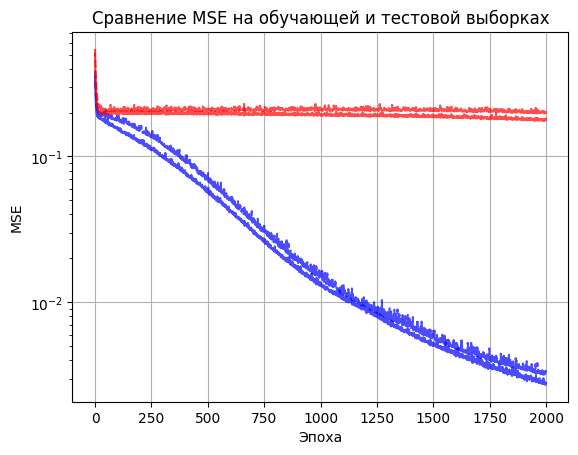

In [73]:
plt.plot(train_mse_relu, 'b-', label='ReLU Train MSE', alpha=0.7)
plt.plot(test_mse_relu, 'b--', label='ReLU Test MSE', alpha=0.7)
plt.plot(train_mse_tanh, 'r-', label='Tanh Train MSE', alpha=0.7)
plt.plot(test_mse_tanh, 'r--', label='Tanh Test MSE', alpha=0.7)
plt.xlabel('Эпоха')
plt.ylabel('MSE')
plt.title('Сравнение MSE на обучающей и тестовой выборках')
plt.yscale('log')
plt.grid()

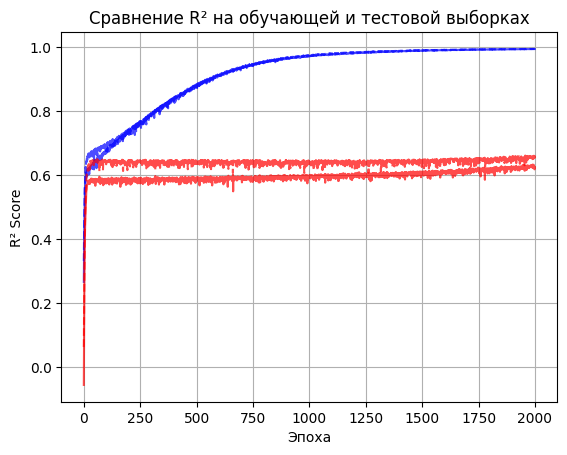

In [74]:
plt.plot(train_r2_relu, 'b-', label='ReLU Train R²', alpha=0.7)
plt.plot(test_r2_relu, 'b--', label='ReLU Test R²', alpha=0.7)
plt.plot(train_r2_tanh, 'r-', label='Tanh Train R²', alpha=0.7)
plt.plot(test_r2_tanh, 'r--', label='Tanh Test R²', alpha=0.7)
plt.xlabel('Эпоха')
plt.ylabel('R² Score')
plt.title('Сравнение R² на обучающей и тестовой выборках')
plt.grid()

## Обратная связь
- [ ] Почта: d83073452@yandex.ru
- [ ] Gmail: 3073452@gmail.com
- [ ] Telegram: @sleepingzzzZ